### Завантаження та підготовка даних


* Викачаємо архів ml-latest-small.zip і розпакуємо.
* Завантажимо таблиці ratings.csv і movies.csv за допомогою pandas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, fpgrowth
from mlxtend.frequent_patterns import association_rules
from pandas import pivot_table

from_csv_ratings = pd.read_csv('ml-latest-small/ratings.csv')
print("Ratings прочитано з CSV:")
print(from_csv_ratings)
print(f"Shape of the ratings table: {from_csv_ratings.shape}")
print(f"Number of unique users: {from_csv_ratings['userId'].nunique()}")
from_csv_movies = pd.read_csv('ml-latest-small/movies.csv')
print("Movies прочитано з CSV:")
print(from_csv_movies)

print(f"Shape of the movies table: {from_csv_movies.shape}")
print(f"Number of unique movies: {from_csv_movies['movieId'].nunique()}")


Ratings прочитано з CSV:
        userId  movieId  rating   timestamp
0            1        1     4.0   964982703
1            1        3     4.0   964981247
2            1        6     4.0   964982224
3            1       47     5.0   964983815
4            1       50     5.0   964982931
...        ...      ...     ...         ...
100831     610   166534     4.0  1493848402
100832     610   168248     5.0  1493850091
100833     610   168250     5.0  1494273047
100834     610   168252     5.0  1493846352
100835     610   170875     3.0  1493846415

[100836 rows x 4 columns]
Shape of the ratings table: (100836, 4)
Number of unique users: 610
Movies прочитано з CSV:
      movieId                                      title  \
0           1                           Toy Story (1995)   
1           2                             Jumanji (1995)   
2           3                    Grumpier Old Men (1995)   
3           4                   Waiting to Exhale (1995)   
4           5         Father

* Виконаємо об’єднання таблиць за полем movieId.

In [2]:
left_merged = pd.merge(from_csv_ratings, from_csv_movies, on='movieId', how='left')
print("Left merged:\n")
print(left_merged)
print(f"\nShape: {left_merged.shape}")
print(f"Size of the left merged table: {left_merged.shape}")


print(f"Number of unique users: {left_merged['userId'].nunique()}, Number of unique movies: {left_merged['movieId'].nunique()}")

Left merged:

        userId  movieId  rating   timestamp                           title  \
0            1        1     4.0   964982703                Toy Story (1995)   
1            1        3     4.0   964981247         Grumpier Old Men (1995)   
2            1        6     4.0   964982224                     Heat (1995)   
3            1       47     5.0   964983815     Seven (a.k.a. Se7en) (1995)   
4            1       50     5.0   964982931      Usual Suspects, The (1995)   
...        ...      ...     ...         ...                             ...   
100831     610   166534     4.0  1493848402                    Split (2017)   
100832     610   168248     5.0  1493850091   John Wick: Chapter Two (2017)   
100833     610   168250     5.0  1494273047                  Get Out (2017)   
100834     610   168252     5.0  1493846352                    Logan (2017)   
100835     610   170875     3.0  1493846415  The Fate of the Furious (2017)   

                                     

* Для подальшого аналізу оберемо лише користувацькі оцінки rating ≥ 4.0, вважаючи, що це “фільми що сподобались користувачам”.

In [3]:
movies_users_liked = left_merged[left_merged['rating'] >= 4]
print(movies_users_liked)

        userId  movieId  rating   timestamp  \
0            1        1     4.0   964982703   
1            1        3     4.0   964981247   
2            1        6     4.0   964982224   
3            1       47     5.0   964983815   
4            1       50     5.0   964982931   
...        ...      ...     ...         ...   
100830     610   166528     4.0  1493879365   
100831     610   166534     4.0  1493848402   
100832     610   168248     5.0  1493850091   
100833     610   168250     5.0  1494273047   
100834     610   168252     5.0  1493846352   

                                      title  \
0                          Toy Story (1995)   
1                   Grumpier Old Men (1995)   
2                               Heat (1995)   
3               Seven (a.k.a. Se7en) (1995)   
4                Usual Suspects, The (1995)   
...                                     ...   
100830  Rogue One: A Star Wars Story (2016)   
100831                         Split (2017)   
100832      

* Виведемо розміри таблиць та кількість унікальних користувачів і фільмів.

In [4]:
print(f"\nShape: {movies_users_liked.shape}")


Shape: (48580, 6)


In [5]:
print(f"Number of unique users: {movies_users_liked['userId'].nunique()}, Number of unique movies: {movies_users_liked['movieId'].nunique()}")

Number of unique users: 609, Number of unique movies: 6298


In [6]:
users_titles = movies_users_liked[['userId','title','rating']]
print(users_titles)

        userId                                title  rating
0            1                     Toy Story (1995)     4.0
1            1              Grumpier Old Men (1995)     4.0
2            1                          Heat (1995)     4.0
3            1          Seven (a.k.a. Se7en) (1995)     5.0
4            1           Usual Suspects, The (1995)     5.0
...        ...                                  ...     ...
100830     610  Rogue One: A Star Wars Story (2016)     4.0
100831     610                         Split (2017)     4.0
100832     610        John Wick: Chapter Two (2017)     5.0
100833     610                       Get Out (2017)     5.0
100834     610                         Logan (2017)     5.0

[48580 rows x 3 columns]


### Перетворення даних у транзакційний формат

Створимо DataFrame у форматі:
*  рядки — користувачі (userId),
*  стовпці — фільми (title),
*  значення — 1, якщо користувач поставив оцінку ≥ 4.0, і 0 інакше.

In [7]:
binary_transaction_matrix = pd.crosstab(movies_users_liked['userId'], movies_users_liked['title']).astype(bool)
print(binary_transaction_matrix.head(20))

title   '71 (2014)  'Hellboy': The Seeds of Creation (2004)  \
userId                                                        
1            False                                    False   
2            False                                    False   
3            False                                    False   
4            False                                    False   
5            False                                    False   
6            False                                    False   
7            False                                    False   
8            False                                    False   
9            False                                    False   
10           False                                    False   
11           False                                    False   
12           False                                    False   
13           False                                    False   
14           False                                    F

#### Пошук частих наборів фільмів

* Використаємо алгоритм Apriori для пошуку частих наборів елементів.

In [25]:
min_support = 0.3

frequent_itemsets_apriori = apriori(binary_transaction_matrix, min_support=min_support, use_colnames=True)

print("Frequent Itemsets (Apriori):\n")
print(f"Minimum support: {min_support}")
print(f"Number of frequent itemsets: {len(frequent_itemsets_apriori)}")
print("\nFrequent itemsets:")
frequent_itemsets_apriori['itemset_length']=frequent_itemsets_apriori['itemsets'].apply(len)
combination_only = frequent_itemsets_apriori[frequent_itemsets_apriori['itemset_length'] >= 1]
print(combination_only.sort_values(['support'], ascending=[False]).head(10))


Frequent Itemsets (Apriori):

Minimum support: 0.3
Number of frequent itemsets: 6

Frequent itemsets:
    support                                           itemsets  itemset_length
3  0.449918      frozenset({Shawshank Redemption, The (1994)})               1
0  0.408867                   frozenset({Forrest Gump (1994)})               1
2  0.400657                   frozenset({Pulp Fiction (1994)})               1
4  0.369458      frozenset({Silence of the Lambs, The (1991)})               1
1  0.364532                    frozenset({Matrix, The (1999)})               1
5  0.330049  frozenset({Star Wars: Episode IV - A New Hope ...               1


In [26]:
min_support = 0.1

frequent_itemsets_apriori = apriori(binary_transaction_matrix, min_support=min_support, use_colnames=True)

print("Frequent Itemsets (Apriori):\n")
print(f"Minimum support: {min_support}")
print(f"Number of frequent itemsets: {len(frequent_itemsets_apriori)}")
print("\nFrequent itemsets:")
frequent_itemsets_apriori['itemset_length']=frequent_itemsets_apriori['itemsets'].apply(len)
combination_only = frequent_itemsets_apriori[frequent_itemsets_apriori['itemset_length'] >= 2]
print(combination_only.sort_values(['support'], ascending=[False]).head(10))


Frequent Itemsets (Apriori):

Minimum support: 0.1
Number of frequent itemsets: 863

Frequent itemsets:
      support                                           itemsets  \
279  0.275862  frozenset({Shawshank Redemption, The (1994), F...   
448  0.259442  frozenset({Shawshank Redemption, The (1994), P...   
449  0.249589  frozenset({Silence of the Lambs, The (1991), P...   
515  0.236453  frozenset({Star Wars: Episode IV - A New Hope ...   
495  0.229885  frozenset({Silence of the Lambs, The (1991), S...   
274  0.223317  frozenset({Pulp Fiction (1994), Forrest Gump (...   
484  0.211823  frozenset({Shawshank Redemption, The (1994), S...   
281  0.210181  frozenset({Silence of the Lambs, The (1991), F...   
411  0.208539  frozenset({Matrix, The (1999), Pulp Fiction (1...   
516  0.206897  frozenset({Star Wars: Episode IV - A New Hope ...   

     itemset_length  
279               2  
448               2  
449               2  
515               2  
495               2  
274            

In [23]:
min_support = 0.05

frequent_itemsets_apriori = apriori(binary_transaction_matrix, min_support=min_support, use_colnames=True)

print("Frequent Itemsets (Apriori):\n")
print(f"Minimum support: {min_support}")
print(f"Number of frequent itemsets: {len(frequent_itemsets_apriori)}")
print("\nFrequent itemsets:")
frequent_itemsets_apriori['itemset_length']=frequent_itemsets_apriori['itemsets'].apply(len)
combination_only = frequent_itemsets_apriori[frequent_itemsets_apriori['itemset_length'] >= 2]
print(combination_only.sort_values(['support'], ascending=[False]).head(10))


Frequent Itemsets (Apriori):

Minimum support: 0.05
Number of frequent itemsets: 33189

Frequent itemsets:
       support                                           itemsets  \
2228  0.275862  frozenset({Shawshank Redemption, The (1994), F...   
3607  0.259442  frozenset({Shawshank Redemption, The (1994), P...   
3610  0.249589  frozenset({Silence of the Lambs, The (1991), P...   
3965  0.236453  frozenset({Star Wars: Episode IV - A New Hope ...   
3823  0.229885  frozenset({Silence of the Lambs, The (1991), S...   
2218  0.223317  frozenset({Pulp Fiction (1994), Forrest Gump (...   
3768  0.211823  frozenset({Shawshank Redemption, The (1994), S...   
2231  0.210181  frozenset({Silence of the Lambs, The (1991), F...   
3260  0.208539  frozenset({Matrix, The (1999), Pulp Fiction (1...   
3966  0.206897  frozenset({Star Wars: Episode IV - A New Hope ...   

      itemset_length  
2228               2  
3607               2  
3610               2  
3965               2  
3823              

#### Побудова асоціативних правил

* Побудуємо асоціативні правила.
* Додамо обчислення метрик support, confidence, lift.

In [30]:
min_confidence = 0.5
rules = association_rules(frequent_itemsets_apriori, metric='confidence', min_threshold=min_confidence)

print("Association Rules:")
print(f"Minimum confidence: {min_confidence}")
print(f"Number of rules: {len(rules)}")

if len(rules) > 0:
    # Display rules with key metrics
    rules_display = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
    rules_display['rule'] = rules_display['antecedents'].astype(str) + ' → ' + rules_display['consequents'].astype(str)

    # Analyze rule quality
    print(f"\nRule Quality Analysis:")
    print(f"Average confidence: {rules['confidence'].mean():.3f}")
    print(f"Average lift: {rules['lift'].mean():.3f}")
    print(f"Rules with lift > 1: {len(rules[rules['lift'] > 1])}")
else:
    print("No rules found with the given confidence threshold.")

Association Rules:
Minimum confidence: 0.5
Number of rules: 1652

Rule Quality Analysis:
Average confidence: 0.681
Average lift: 2.415
Rules with lift > 1: 1652


* Відсортуємо та виведемо топ-10 правил за lift.

In [32]:
print("\nTop rules by confidence:")
rules_display.sort_values('lift', ascending=False).head(10)


Top rules by confidence:


,antecedents,consequents,support,confidence,lift,rule
230,frozenset({Kill Bill: Vol. 2 (2004)}),frozenset({Kill Bill: Vol. 1 (2003)}),0.106732,0.902778,6.247633,frozenset({'Kill Bill: Vol. 2 (2004)'}) → froz...
229,frozenset({Kill Bill: Vol. 1 (2003)}),frozenset({Kill Bill: Vol. 2 (2004)}),0.106732,0.738636,6.247633,frozenset({'Kill Bill: Vol. 1 (2003)'}) → froz...
1466,frozenset({Star Wars: Episode V - The Empire S...,frozenset({Star Wars: Episode IV - A New Hope ...,0.106732,0.613208,4.668042,frozenset({'Star Wars: Episode V - The Empire ...
1463,frozenset({Star Wars: Episode IV - A New Hope ...,frozenset({Star Wars: Episode V - The Empire S...,0.106732,0.812500,4.668042,frozenset({'Star Wars: Episode IV - A New Hope...
758,"frozenset({Goodfellas (1990), Godfather, The (...","frozenset({Godfather: Part II, The (1974)})",0.100164,0.792208,4.508921,"frozenset({'Goodfellas (1990)', 'Godfather, Th..."
761,"frozenset({Godfather: Part II, The (1974)})","frozenset({Goodfellas (1990), Godfather, The (...",0.100164,0.570093,4.508921,"frozenset({'Godfather: Part II, The (1974)'}) ..."
1486,"frozenset({Matrix, The (1999), Lord of the Rin...",frozenset({Lord of the Rings: The Fellowship o...,0.123153,0.882353,4.440933,"frozenset({'Matrix, The (1999)', 'Lord of the ..."
1485,frozenset({Lord of the Rings: The Fellowship o...,"frozenset({Matrix, The (1999), Lord of the Rin...",0.123153,0.619835,4.440933,frozenset({'Lord of the Rings: The Fellowship ...
1340,frozenset({Lord of the Rings: The Fellowship o...,"frozenset({Lord of the Rings: The Two Towers, ...",0.105090,0.528926,4.412544,frozenset({'Lord of the Rings: The Fellowship ...
1341,"frozenset({Lord of the Rings: The Two Towers, ...",frozenset({Lord of the Rings: The Fellowship o...,0.105090,0.876712,4.412544,"frozenset({'Lord of the Rings: The Two Towers,..."


* Візуалізуємо розподіл метрик (графіки support–confidence, lift–confidence тощо).


### Графік залежності confidence від support

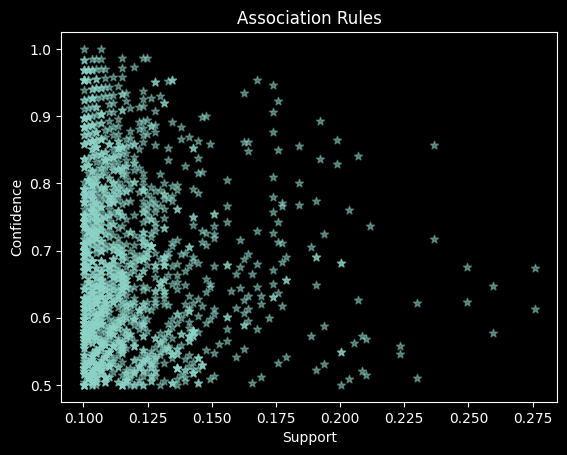

In [36]:
plt.scatter(rules['support'], rules['confidence'], alpha=0.5, marker='*')
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Association Rules")
plt.show()

### Графік залежності confidence від support

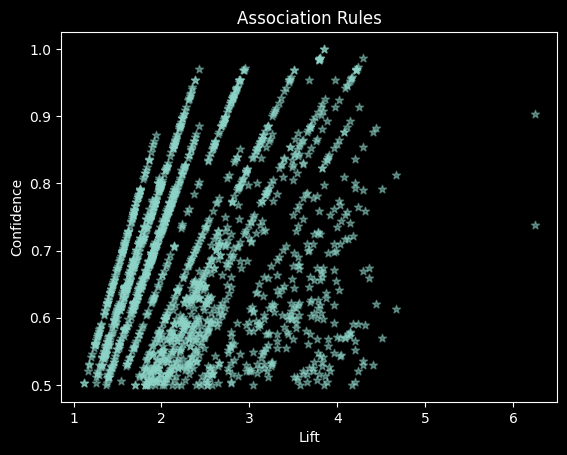

In [38]:
plt.scatter(rules['lift'], rules['confidence'], alpha=0.5, marker='*')
plt.xlabel("Lift")
plt.ylabel("Confidence")
plt.title("Association Rules")
plt.show()